# Music Popularity Prediction Analysis

This notebook tests whether the available Spotify-style audio and metadata features can predict a track's `Popularity` score. The focus is reproducibility and fair comparison: clean the dataset, compare against a mean baseline, evaluate multiple practical regressors, and state whether the result is conclusive.


## 1. Setup

The CSV is loaded with a relative path so the notebook can run from the project root on any machine.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
DATA_PATH = Path("music_popularity.csv")


In [2]:
raw_df = pd.read_csv(DATA_PATH)
raw_df.head()


,Unnamed: 0,Track Name,Artists,Album Name,Album ID,Track ID,Popularity,Release Date,Duration (ms),Explicit,...,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
0,0,Not Like Us,Kendrick Lamar,Not Like Us,5JjnoGJyOxfSZUZtk2rRwZ,6AI3ezQ4o3HUoP6Dhudph3,96,2024-05-04,274192,True,...,0.472,1,-7.001,1,0.0776,0.0107,0.000000,0.1410,0.214,101.061
1,1,Houdini,Eminem,Houdini,6Xuu2z00jxRPZei4IJ9neK,2HYFX63wP3otVIvopRS99Z,94,2024-05-31,227239,True,...,0.887,9,-2.760,0,0.0683,0.0292,0.000002,0.0582,0.889,127.003
2,2,BAND4BAND (feat. Lil Baby),"Central Cee, Lil Baby",BAND4BAND (feat. Lil Baby),4AzPr5SUpNF553eC1d3aRy,7iabz12vAuVQYyekFIWJxD,91,2024-05-23,140733,True,...,0.764,11,-5.241,1,0.2040,0.3590,0.000000,0.1190,0.886,140.113
3,3,I Don't Wanna Wait,"David Guetta, OneRepublic",I Don't Wanna Wait,0wCLHkBRKcndhMQQpeo8Ji,331l3xABO0HMr1Kkyh2LZq,90,2024-04-05,149668,False,...,0.714,1,-4.617,0,0.0309,0.0375,0.000000,0.2320,0.554,129.976
4,4,Pedro,"Jaxomy, Agatino Romero, Raffaella CarrÃ",Pedro,5y6RXjI5VPR0RyInghTbf1,48lxT5qJF0yYyf2z4wB4xW,89,2024-03-29,144846,False,...,0.936,9,-6.294,1,0.3010,0.0229,0.000001,0.3110,0.844,151.019


## 2. Data Cleaning

The raw file includes an index-like `Unnamed: 0` column, duplicate Spotify `Track ID` values, and visible text encoding artifacts in some names such as `TiÃ«sto`. The encoding issue affects display labels, not the numeric modeling features used below.


In [3]:
def clean_music_data(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()

    if "Unnamed: 0" in cleaned.columns:
        cleaned = cleaned.drop(columns=["Unnamed: 0"])

    cleaned["Release Date"] = pd.to_datetime(cleaned["Release Date"], errors="coerce")
    cleaned = cleaned.drop_duplicates(subset="Track ID", keep="first").reset_index(drop=True)

    cleaned["release_year"] = cleaned["Release Date"].dt.year
    latest_release = cleaned["Release Date"].max()
    cleaned["track_age_days"] = (latest_release - cleaned["Release Date"]).dt.days
    cleaned["duration_minutes"] = cleaned["Duration (ms)"] / 60000
    cleaned["explicit_int"] = cleaned["Explicit"].astype(int)

    return cleaned

before_rows = len(raw_df)
before_unique_tracks = raw_df["Track ID"].nunique()
df = clean_music_data(raw_df)

data_quality_summary = pd.DataFrame({
    "metric": [
        "raw_rows",
        "rows_after_deduping_track_id",
        "duplicate_track_id_rows_removed",
        "unique_track_ids_raw",
        "missing_values_after_cleaning",
    ],
    "value": [
        before_rows,
        len(df),
        before_rows - len(df),
        before_unique_tracks,
        int(df.isna().sum().sum()),
    ],
})
data_quality_summary


,metric,value
0,raw_rows,227
1,rows_after_deduping_track_id,212
2,duplicate_track_id_rows_removed,15
3,unique_track_ids_raw,212
4,missing_values_after_cleaning,0


In [4]:
mojibake_mask = df.astype(str).apply(
    lambda col: col.str.contains("Ã|â|�", regex=True, na=False)
).any(axis=1)

df.loc[mojibake_mask, ["Track Name", "Artists", "Album Name"]].head(10)


,Track Name,Artists,Album Name
4,Pedro,"Jaxomy, Agatino Romero, Raffaella CarrÃ",Pedro
7,Prada,"cassÃ¶, RAYE, D-Block Europe",Prada
11,Thank You (Not So Bad),"Dimitri Vegas & Like Mike, TiÃ«sto, Dido, W&W,...",Thank You (Not So Bad)
29,TitÃ­ Me PreguntÃ³,Bad Bunny,Un Verano Sin Ti
48,DerniÃ¨re danse - Techno Mix,"Indila, BENNETT",DerniÃ¨re danse (Techno Mix)
55,Lay Low,TiÃ«sto,Lay Low
62,10:35,"TiÃ«sto, Tate McRae",10:35
71,Bad Memories (feat. Elley DuhÃ© & FAST BOY),"MEDUZA, James Carter, Elley DuhÃ©, FAST BOY",Bad Memories (feat. Elley DuhÃ© & FAST BOY)
72,The Motto,"TiÃ«sto, Ava Max",The Motto
82,La Jumpa,"ArcÃ¡ngel, Bad Bunny",La Jumpa


## 3. Exploratory Checks

These checks summarize the target distribution and the numeric relationships with `Popularity`. Correlation is useful orientation, but it does not prove predictive power.


In [5]:
df.describe(include="all").transpose()


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Track Name,212,211,"Ve Kamleya (From ""Rocky Aur Rani Kii Prem Kaha...",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Artists,212,195,"Pritam, Arijit Singh",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Album Name,212,201,Kabir Singh,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Album ID,212,201,3uuu6u13U0KeVQsZ3CZKK4,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Track ID,212,212,6AI3ezQ4o3HUoP6Dhudph3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Popularity,212.0,NaN,NaN,NaN,71.669811,13.0,67.0,72.0,78.0,96.0,10.496871
Release Date,212,NaN,NaN,NaN,2021-06-09 07:41:53.207547136,2001-10-19 00:00:00,2019-06-14 00:00:00,2022-09-16 00:00:00,2023-11-25 18:00:00,2024-05-31 00:00:00,NaN
Duration (ms),212.0,NaN,NaN,NaN,216875.929245,96947.0,166365.75,213444.0,264148.5,383639.0,60995.107832
Explicit,212,2,False,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
External URLs,212,212,https://open.spotify.com/track/6AI3ezQ4o3HUoP6...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
numeric_corr = df.select_dtypes(include=[np.number]).corr(numeric_only=True)
popularity_corr = numeric_corr["Popularity"].sort_values(ascending=False)
popularity_corr


Popularity          1.000000
explicit_int        0.424494
release_year        0.334297
Loudness            0.329359
Danceability        0.291999
Energy              0.282127
Speechiness         0.203675
Tempo               0.164198
Instrumentalness    0.109788
Liveness            0.072327
Mode               -0.008058
Key                -0.012435
Valence            -0.043372
duration_minutes   -0.283646
Duration (ms)      -0.283646
track_age_days     -0.337326
Acousticness       -0.476050
Name: Popularity, dtype: float64

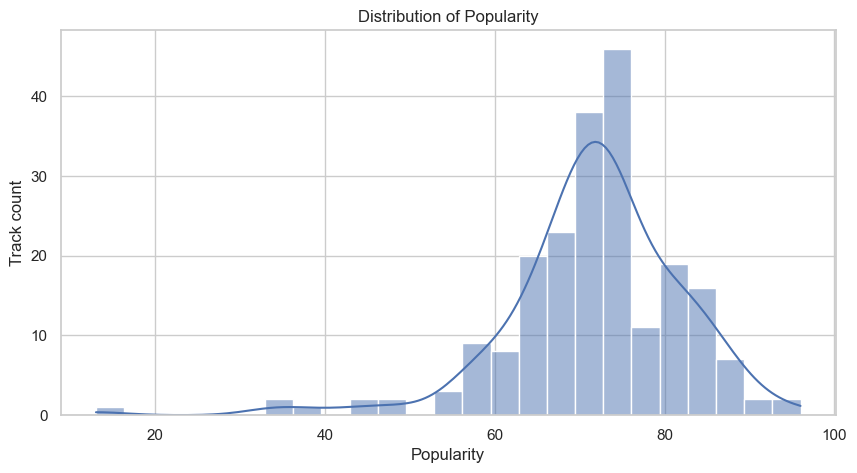

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Popularity"], kde=True, bins=25)
plt.title("Distribution of Popularity")
plt.xlabel("Popularity")
plt.ylabel("Track count")
plt.show()


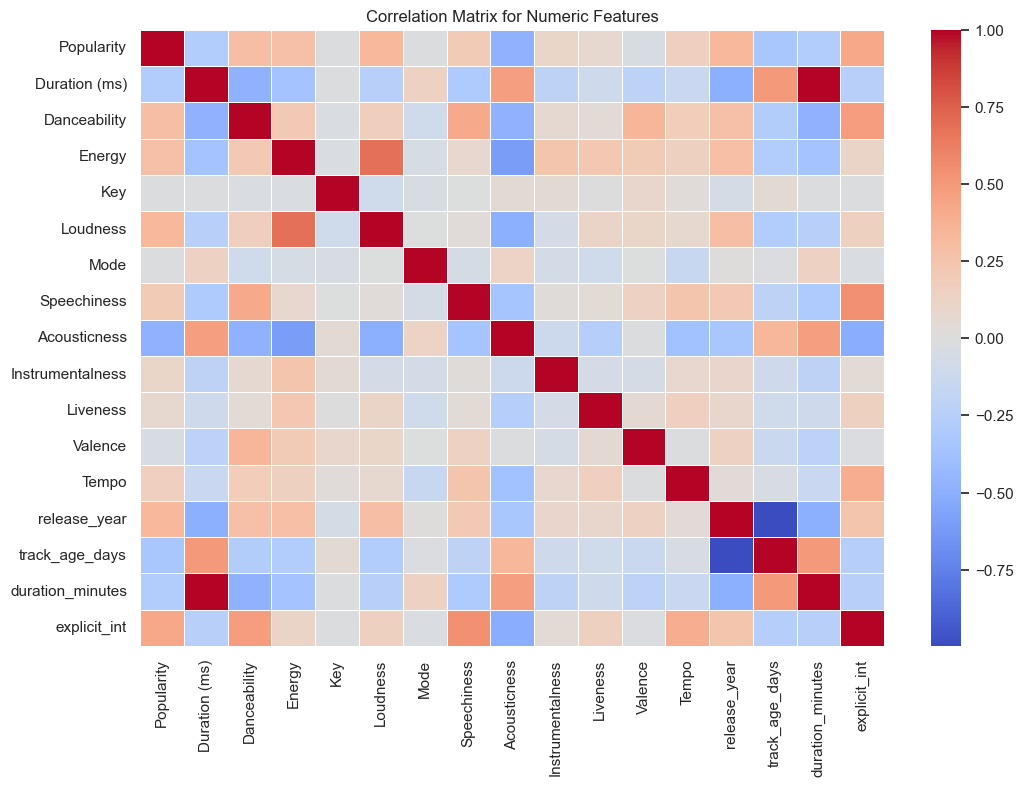

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix for Numeric Features")
plt.show()


## 4. Feature Sets

Two feature sets are compared. The core feature set uses only audio descriptors. The expanded feature set adds derived values from existing columns, without using text identifiers that could encourage memorization.


In [9]:
core_features = [
    "Energy",
    "Valence",
    "Danceability",
    "Loudness",
    "Acousticness",
    "Tempo",
    "Speechiness",
    "Liveness",
]

expanded_features = core_features + [
    "duration_minutes",
    "explicit_int",
    "release_year",
    "track_age_days",
]

target = "Popularity"
feature_sets = {
    "core_audio": core_features,
    "expanded_existing_csv": expanded_features,
}

feature_audit = pd.DataFrame({
    "feature_set": list(feature_sets.keys()),
    "feature_count": [len(features) for features in feature_sets.values()],
    "features": [", ".join(features) for features in feature_sets.values()],
})
feature_audit


,feature_set,feature_count,features
0,core_audio,8,"Energy, Valence, Danceability, Loudness, Acous..."
1,expanded_existing_csv,12,"Energy, Valence, Danceability, Loudness, Acous..."


## 5. Model Evaluation

The evaluation uses 5-fold shuffled cross-validation and compares every model to a mean baseline. Metrics are reported as mean and standard deviation across folds:

- `R2`: higher is better; values near or below 0 mean weak predictive value.
- `MAE`: average absolute popularity-score error; lower is better.
- `RMSE`: larger errors are penalized more; lower is better.


In [10]:
def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": make_scorer(rmse, greater_is_better=False),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scaled_preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), expanded_features)],
    remainder="drop",
)

models = {
    "Baseline mean": DummyRegressor(strategy="mean"),
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        max_features=None,
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

results = []
for feature_set_name, features in feature_sets.items():
    X = df[features]
    y = df[target]

    for model_name, model in models.items():
        cv_results = cross_validate(
            model,
            X,
            y,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
        )
        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "r2_mean": cv_results["test_r2"].mean(),
            "r2_std": cv_results["test_r2"].std(),
            "mae_mean": -cv_results["test_mae"].mean(),
            "mae_std": cv_results["test_mae"].std(),
            "rmse_mean": -cv_results["test_rmse"].mean(),
            "rmse_std": cv_results["test_rmse"].std(),
        })

results_df = pd.DataFrame(results).sort_values("r2_mean", ascending=False).reset_index(drop=True)
results_df


,feature_set,model,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
0,expanded_existing_csv,Ridge Regression,0.221786,0.079346,6.252451,0.895244,8.865417,1.913097
1,expanded_existing_csv,Linear Regression,0.215258,0.082630,6.294374,0.879900,8.897142,1.904500
2,core_audio,Ridge Regression,0.172940,0.142554,6.532250,1.106374,9.091589,1.993393
3,core_audio,Linear Regression,0.172109,0.142626,6.539830,1.101819,9.095308,1.989806
4,expanded_existing_csv,Gradient Boosting,0.135654,0.230123,6.271958,0.851827,9.173375,1.810703
5,core_audio,Random Forest,0.118957,0.260475,6.642654,0.703051,9.179613,1.498772
6,expanded_existing_csv,Random Forest,0.117199,0.280239,6.434624,0.882801,9.217656,1.861280
7,core_audio,Gradient Boosting,0.102346,0.203923,6.587955,0.713866,9.355622,1.672936
8,core_audio,Baseline mean,-0.070365,0.104503,7.317693,0.941561,10.355342,2.000752
9,expanded_existing_csv,Baseline mean,-0.070365,0.104503,7.317693,0.941561,10.355342,2.000752


## 6. Modest Random Forest Tuning

The Random Forest search space is intentionally modest so it is appropriate for a small dataset. The old automatic max-feature option is not used because it is invalid/deprecated for current scikit-learn versions.


In [11]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "max_features": [None, "sqrt", "log2"],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

tuned_results = []
tuned_estimators = {}

for feature_set_name, features in feature_sets.items():
    X = df[features]
    y = df[target]

    search = GridSearchCV(
        estimator=RandomForestRegressor(random_state=RANDOM_STATE),
        param_grid=rf_param_grid,
        scoring="r2",
        cv=cv,
        n_jobs=1,
        refit=True,
    )
    search.fit(X, y)
    tuned_estimators[feature_set_name] = search.best_estimator_

    tuned_cv = cross_validate(
        search.best_estimator_,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
    )
    tuned_results.append({
        "feature_set": feature_set_name,
        "model": "Tuned Random Forest",
        "r2_mean": tuned_cv["test_r2"].mean(),
        "r2_std": tuned_cv["test_r2"].std(),
        "mae_mean": -tuned_cv["test_mae"].mean(),
        "mae_std": tuned_cv["test_mae"].std(),
        "rmse_mean": -tuned_cv["test_rmse"].mean(),
        "rmse_std": tuned_cv["test_rmse"].std(),
        "best_params": search.best_params_,
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df


,feature_set,model,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std,best_params
0,core_audio,Tuned Random Forest,0.216349,0.095654,6.343950,0.954194,8.869567,1.845580,"{'max_depth': 10, 'max_features': 'sqrt', 'min..."
1,expanded_existing_csv,Tuned Random Forest,0.260731,0.081791,5.966934,0.782680,8.652307,1.942385,"{'max_depth': None, 'max_features': 'sqrt', 'm..."


In [12]:
all_results_df = pd.concat(
    [results_df, tuned_results_df.drop(columns=["best_params"], errors="ignore")],
    ignore_index=True,
).sort_values("r2_mean", ascending=False).reset_index(drop=True)

baseline_rows = all_results_df[all_results_df["model"] == "Baseline mean"]
best_baseline = baseline_rows.sort_values("r2_mean", ascending=False).iloc[0]
best_model_row = all_results_df[all_results_df["model"] != "Baseline mean"].iloc[0]

improvement_summary = pd.DataFrame({
    "metric": ["best_model", "best_feature_set", "best_r2_mean", "baseline_r2_mean", "r2_lift", "best_mae_mean", "baseline_mae_mean", "mae_lift"],
    "value": [
        best_model_row["model"],
        best_model_row["feature_set"],
        best_model_row["r2_mean"],
        best_baseline["r2_mean"],
        best_model_row["r2_mean"] - best_baseline["r2_mean"],
        best_model_row["mae_mean"],
        best_baseline["mae_mean"],
        best_baseline["mae_mean"] - best_model_row["mae_mean"],
    ],
})

all_results_df


,feature_set,model,r2_mean,r2_std,mae_mean,mae_std,rmse_mean,rmse_std
0,expanded_existing_csv,Tuned Random Forest,0.260731,0.081791,5.966934,0.782680,8.652307,1.942385
1,expanded_existing_csv,Ridge Regression,0.221786,0.079346,6.252451,0.895244,8.865417,1.913097
2,core_audio,Tuned Random Forest,0.216349,0.095654,6.343950,0.954194,8.869567,1.845580
3,expanded_existing_csv,Linear Regression,0.215258,0.082630,6.294374,0.879900,8.897142,1.904500
4,core_audio,Ridge Regression,0.172940,0.142554,6.532250,1.106374,9.091589,1.993393
5,core_audio,Linear Regression,0.172109,0.142626,6.539830,1.101819,9.095308,1.989806
6,expanded_existing_csv,Gradient Boosting,0.135654,0.230123,6.271958,0.851827,9.173375,1.810703
7,core_audio,Random Forest,0.118957,0.260475,6.642654,0.703051,9.179613,1.498772
8,expanded_existing_csv,Random Forest,0.117199,0.280239,6.434624,0.882801,9.217656,1.861280
9,core_audio,Gradient Boosting,0.102346,0.203923,6.587955,0.713866,9.355622,1.672936


In [13]:
improvement_summary


,metric,value
0,best_model,Tuned Random Forest
1,best_feature_set,expanded_existing_csv
2,best_r2_mean,0.260731
3,baseline_r2_mean,-0.070365
4,r2_lift,0.331096
5,best_mae_mean,5.966934
6,baseline_mae_mean,7.317693
7,mae_lift,1.350759


## 7. Actual vs Predicted for Best Model

This plot uses cross-validated predictions for the best non-baseline model, so each point is predicted by a model that did not train on that row.


In [14]:
def build_model_from_row(row):
    model_name = row["model"]
    feature_set_name = row["feature_set"]

    if model_name == "Tuned Random Forest":
        return clone(tuned_estimators[feature_set_name])
    return clone(models[model_name])

best_features = feature_sets[best_model_row["feature_set"]]
best_estimator = build_model_from_row(best_model_row)

X_best = df[best_features]
y = df[target]
y_pred_cv = cross_val_predict(best_estimator, X_best, y, cv=cv)

plot_metrics = {
    "R2": r2_score(y, y_pred_cv),
    "MAE": mean_absolute_error(y, y_pred_cv),
    "RMSE": rmse(y, y_pred_cv),
}
plot_metrics


{'R2': 0.2829918497720072, 'MAE': 5.964584995847966, 'RMSE': 8.867377490341237}

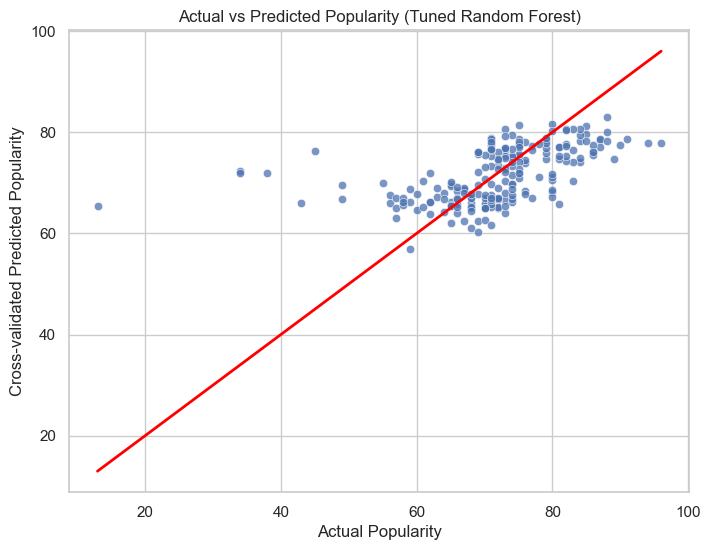

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred_cv, alpha=0.75)
min_value = min(y.min(), y_pred_cv.min())
max_value = max(y.max(), y_pred_cv.max())
plt.plot([min_value, max_value], [min_value, max_value], color="red", linewidth=2)
plt.title(f"Actual vs Predicted Popularity ({best_model_row['model']})")
plt.xlabel("Actual Popularity")
plt.ylabel("Cross-validated Predicted Popularity")
plt.show()


## 8. Conclusion

The best practical model should be judged against the mean baseline, not in isolation. If the best model only modestly improves `R2`, `MAE`, or `RMSE`, the outcome is useful but not conclusive.


In [16]:
conclusion = (
    f"Best model: {best_model_row['model']} using {best_model_row['feature_set']} features. "
    f"Mean CV R2 = {best_model_row['r2_mean']:.3f} +/- {best_model_row['r2_std']:.3f}; "
    f"MAE = {best_model_row['mae_mean']:.2f} +/- {best_model_row['mae_std']:.2f}. "
    f"The mean baseline R2 = {best_baseline['r2_mean']:.3f} and MAE = {best_baseline['mae_mean']:.2f}. "
    "Because the dataset is small and popularity depends on major external factors not present in this CSV, "
    "these results should be treated as exploratory rather than conclusive."
)
print(conclusion)


Best model: Tuned Random Forest using expanded_existing_csv features. Mean CV R2 = 0.261 +/- 0.082; MAE = 5.97 +/- 0.78. The mean baseline R2 = -0.070 and MAE = 7.32. Because the dataset is small and popularity depends on major external factors not present in this CSV, these results should be treated as exploratory rather than conclusive.
